In [14]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 한글 폰트 설정(윈도우)
plt.rcParams['font.family'] = 'Malgun Gothic'

In [16]:
# 데이터 로드
mpg = sns.load_dataset("mpg")
mpg.info()
mpg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


# 선그래프

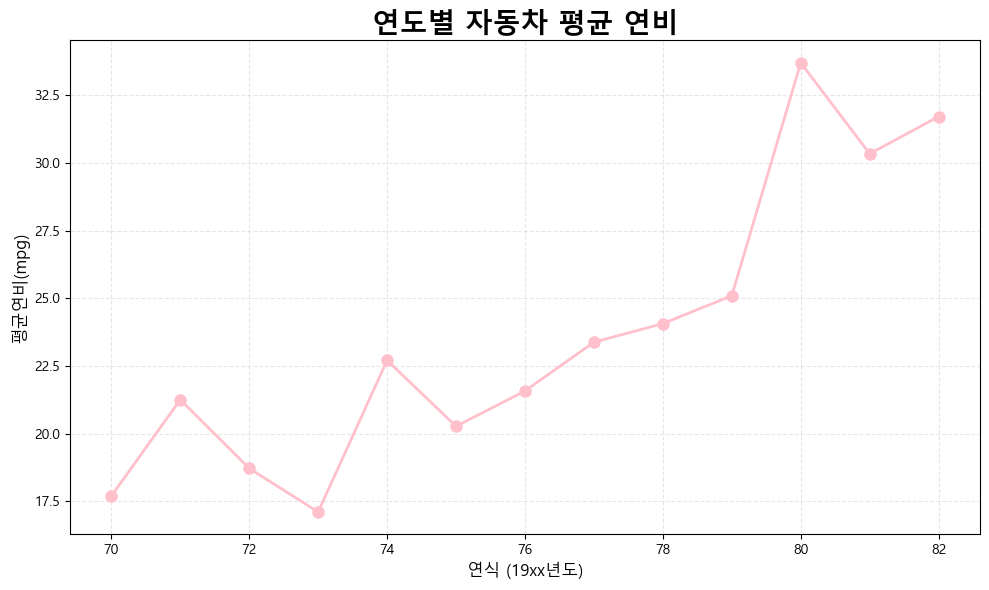

In [17]:
# 연도별 평균 연비 계산
yearly_mpg = mpg.groupby('model_year')['mpg'].mean()

# 객체지향 방식
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(yearly_mpg.index, yearly_mpg.values,
        marker = 'o', linewidth = 2, markersize = 8, color = 'pink')
ax.set_xlabel('연식 (19xx년도)', fontsize = 12)
ax.set_ylabel('평균연비(mpg)', fontsize = 12)
ax.set_title('연도별 자동차 평균 연비', fontsize = 20, fontweight = 'bold')
ax.grid(True, alpha = 0.3, linestyle = '--')   # alpha는 투명도
plt.tight_layout()
plt.show()

# 인사이트: 1970년대 중반부터 연비가 급격히 개선 -> 오일쇼크 이후 연비 규제 강화 영향

In [18]:
# 제조사 확인
mpg['origin'].unique()

array(['usa', 'japan', 'europe'], dtype=object)

# 막대그래프

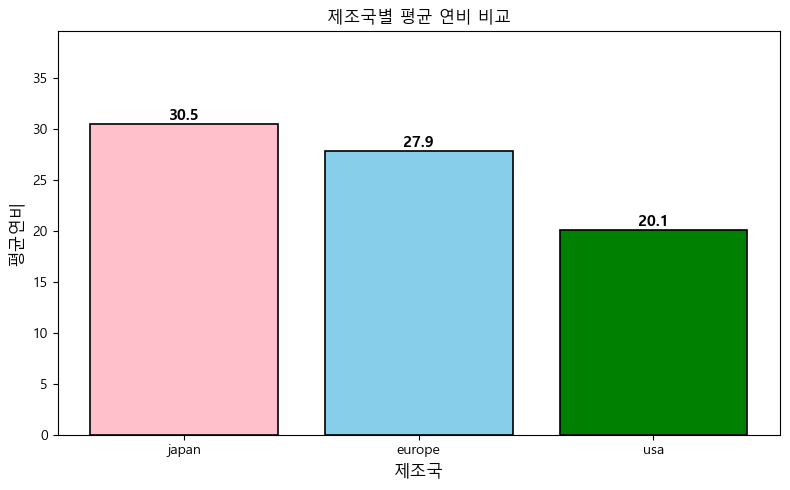

In [27]:
# 제조국(origin별) 평균 연비 mpg
origin_mpg = mpg.groupby('origin')['mpg'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(origin_mpg.index, origin_mpg.values, color = ['pink', 'skyblue', 'green'],
       edgecolor = 'black', linewidth = 1.2)

# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}',
            ha='center', va = 'bottom', fontsize = 11, fontweight='bold')
    
ax.set_xlabel('제조국', fontsize = 12)
ax.set_ylabel('평균연비', fontsize = 12)
ax.set_title('제조국별 평균 연비 비교')
ax.set_ylim(0, origin_mpg.max()*1.3)
plt.tight_layout()
plt.show()

# 인사이트: 일본 차량이 평균 30.5mpg로 가장 효율적 -> 소형차 중심 전략

# 산점도